# 01 — First look at the data
Run from the `notebooks/` directory. Each step prints one thing, then explains what it means. Deeper evidence lives in `02`, experiments in `03`.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
tr = pd.read_csv('../data/train_test.csv', parse_dates=['date'])
va = pd.read_csv('../data/validation.csv', parse_dates=['date'])
print('train rows, cols:', tr.shape)
print('validation rows, cols:', va.shape)

train rows, cols: (48000, 14)
validation rows, cols: (12000, 13)


**What this means:** 48,000 training rows with 14 columns vs 12,000 validation rows with 13 columns. The missing column in validation is `posted_rate` — the price we must predict.

In [2]:
print('train dates:', tr['date'].min().date(), '->', tr['date'].max().date())
print('valid dates:', va['date'].min().date(), '->', va['date'].max().date())

train dates: 2025-01-01 -> 2025-10-31
valid dates: 2025-11-01 -> 2025-12-31


**What this means:** training is Jan–Oct, validation is Nov–Dec — strictly in the future. Any validation that mixes these periods leaks the future, so our cross-validation must respect time order.

In [3]:
print('weight NaN:', tr['weight'].isna().sum())
print('negative weights:', (tr['weight'] < 0).sum())
print('weights at exactly +-47500:', (tr['weight'].abs() == 47500).sum())

weight NaN: 300
negative weights: 292
weights at exactly +-47500: 1204


**What this means:** three separate weight problems — missing values to impute, impossible negatives (sign errors) to fix with `abs()`, and a pile-up at 47,500 that reveals a system cap (see notebook 02 for the proof).

In [4]:
print('market NaN train:', tr['market_index'].isna().sum(), '| val:', va['market_index'].isna().sum())
print('market mean train: %.3f | val: %.3f' % (tr['market_index'].mean(), va['market_index'].mean()))

market NaN train: 374 | val: 249
market mean train: 1.083 | val: 0.927


**What this means:** the market regime shifted (1.08 vs 0.93) between training and test. A model trusting raw market values will misfire — we smooth them instead.

In [5]:
tr['rpm'] = tr['posted_rate'] / tr['distance']
print(tr.groupby('equipment')['rpm'].median().round(3).to_string())

equipment
Dry Van    2.046
Flatbed    2.220
Reefer     2.312


**What this means:** price-per-mile differs by trailer type — Reefers cost most per mile, Dry Vans least. Equipment matters, so the model gets it as a feature.

In [6]:
print('corr distance-rate: %.3f' % tr['distance'].corr(tr['posted_rate']))

corr distance-rate: 0.909


**What this means:** 0.91 is extremely high (scale: -1 to +1). Distance alone explains most of the price — our naive baseline (median $/mile x distance) already gets MAE 219 on this fact alone.

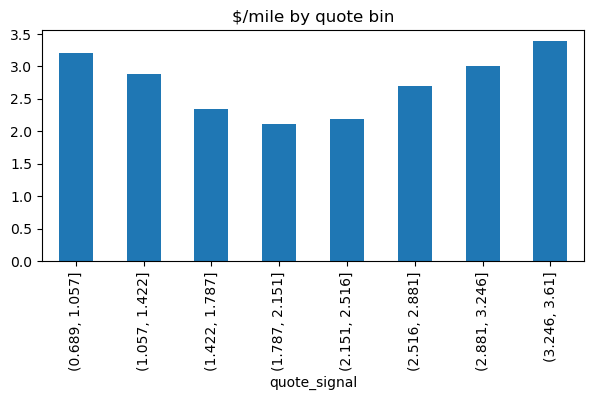

In [7]:
qb = tr.groupby(pd.cut(tr['quote_signal'], 8), observed=True)['rpm'].mean()
qb.plot.bar(figsize=(7, 3), title='$/mile by quote bin'); plt.show()

**What this means:** a U-shape — both signal extremes are expensive (~3.2–3.4 $/mi), the middle is cheap (~2.1). Correlation reads ~0 because it only sees straight lines. Trees see this curve; linear models cannot. Hence `qs_dev` in features.

In [8]:
tr['month'] = tr['date'].dt.to_period('M')
print(tr.groupby('month', observed=True)['rpm'].mean().round(3).to_string())

month
2025-01    2.100
2025-02    2.123
2025-03    2.206
2025-04    2.210
2025-05    2.260
2025-06    2.332
2025-07    2.256
2025-08    2.189
2025-09    2.230
2025-10    2.240
Freq: M


**What this means:** $/mile climbs from ~2.10 (Jan) to ~2.33 (Jun), then settles ~2.24 — a time trend independent of the market index. Hence the `trend` and `month` features.